# Ujian Tengah Semester - Genap 2025/2026
## Klasifikasi Teks: Deteksi Ujaran Kebencian (Hate Speech) pada Tweet Berbahasa Indonesia

**Nama:** Dewa Satria

**NIM:** 25917017

**Mata Kuliah:** Analisis Teks

**Dosen:** Dhomas Hatta Fudholi, Ph.D.

---
**Link Repositori GitHub:** https://github.com/dewasatria11/Klasifikasi-Teks-Deteksi-Ujaran-Kebencian-Hate-Speech-pada-Tweet-Berbahasa-Indonesia


## Daftar Isi
1. [Bagian 0: Artikel Isu Terkini dan Solusi Klasifikasi Teks](#bagian-0)
2. [Bagian 1: Pengumpulan Data](#bagian-1)
3. [Bagian 2: Pra-Pemrosesan Teks](#bagian-2)
4. [Bagian 3: Rekayasa Fitur](#bagian-3)
5. [Bagian 4: Analisis Data Eksploratif dan Visualisasi](#bagian-4)
6. [Bagian 5: Klasifikasi Teks](#bagian-5)
7. [Bagian 6: Soal Teori](#bagian-6)
8. [Referensi](#referensi)

<a id='bagian-0'></a>
# Bagian 0: Artikel Isu Terkini dan Solusi Klasifikasi Teks

## Isu yang Diangkat

Saya memilih **artikel ilmiah** berjudul **"Analisis Penyebaran Informasi Palsu dan Ujaran Kebencian di Media Sosial Indonesia : Studi Kasus Berita Hoax dan Hate Speech"** yang ditulis oleh S. Ramadhani dan diterbitkan pada tahun 2025 di jurnal **Publistik: Jurnal Ilmu Komunikasi** (ejurnal.iainpare.ac.id).

**Link Artikel:** https://ejurnal.iainpare.ac.id/index.php/publistikji/article/view/14654/2959

**Link Download PDF (full artikel):** https://ejurnal.iainpare.ac.id/index.php/publistikji/article/download/14654/2959

### Ringkasan Isu dari Artikel:
Artikel ini menggunakan pendekatan **studi kasus kualitatif** dengan **analisis wacana kritis** terhadap konten media sosial dan dokumentasi lembaga terkait. Fokus utama pada dinamika penyebaran hoax dan hate speech selama periode pemilu dan isu-isu sensitif di Indonesia (2019–2023).

- Hoax dan ujaran kebencian (hate speech) di media sosial menjadi tantangan serius bagi kebebasan berekspresi dan stabilitas sosial di Indonesia.
- Hoax dan hate speech **kerap dimanfaatkan sebagai alat politik dan provokasi**.
- Berdampak negatif pada **kerukunan masyarakat**.
- Peran media, pemerintah, dan masyarakat sipil sangat krusial dalam menangkal penyebaran informasi palsu dan ujaran kebencian.
- Diperlukan **literasi digital** yang lebih baik dan strategi komprehensif.

## Solusi yang Diusulkan: Klasifikasi Teks untuk Deteksi Ujaran Kebencian / Hoax

Dari isu yang diangkat dalam artikel tersebut, solusi berbasis **Text Classification** sangat relevan dan aplikatif:
- Membangun model machine learning yang dapat **mengklasifikasikan teks** (tweet, postingan, atau berita) secara otomatis apakah mengandung **ujaran kebencian (Hate Speech)** atau **hoax/misinformasi**.
- Manfaat langsung:
  - Membantu platform media sosial dan pemerintah dalam **moderasi konten** secara real-time dan berskala besar.
  - Mendukung penegakan hukum (UU ITE, KUHP baru) dengan deteksi dini konten berbahaya.
  - Memberikan data berbasis AI untuk riset lebih lanjut dan kebijakan literasi digital.
  - Mengurangi dampak negatif terhadap kerukunan sosial dan kesehatan mental masyarakat.

Pendekatan ini menggunakan **supervised learning** dengan dataset berlabel dari Twitter Indonesia yang relevan dengan konteks isu di artikel.


<a id='bagian-1'></a>
# Bagian 1: Pengumpulan Data

## 1. Penjelasan Dataset

- **Nama Dataset**: Indonesian Multi-label Hate Speech and Abusive Language Detection Twitter Dataset
- **Sumber**: Repositori GitHub resmi dari peneliti asli - https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection
  - Paper pendukung: Ibrohim, M.O. & Budi, I. (2019). Multi-label Hate Speech and Abusive Language Detection in Indonesian Twitter. *Proceedings of the Third Workshop on Abusive Language Online*, hal. 46-57. Association for Computational Linguistics.
- **Jumlah Sampel**: 13.169 tweet berbahasa Indonesia (setelah preprocessing oleh penulis asli).
- **Fitur Utama**:
  - `Tweet`: Teks tweet (sudah dianonimkan USER dan URL)
  - Label multi-label biner (0/1):
    - `HS`: Hate Speech (target utama kita)
    - `Abusive`: Bahasa kasar/abusive
    - `HS_Individual`, `HS_Group`, `HS_Religion`, `HS_Race`, `HS_Physical`, `HS_Gender`, `HS_Other`
    - `HS_Weak`, `HS_Moderate`, `HS_Strong` (tingkat keparahan)

Untuk tugas ini, kami **menyederhanakan menjadi klasifikasi biner**: `HS` (1 = mengandung hate speech, 0 = tidak).
Ini sesuai dengan tujuan mendeteksi keberadaan ujaran kebencian.


## 2. Kode Pengumpulan Data

In [ ]:
# Instalasi library yang diperlukan (jalankan sekali saja di Colab/Jupyter dengan internet)
!pip install pandas scikit-learn nltk gensim matplotlib seaborn wordcloud Sastrawi numpy --quiet

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Untuk NLP Indonesia
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download resource NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print('Semua library berhasil diimpor!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 14.0 MB/s eta 0:00:00
Semua library berhasil diimpor!


In [ ]:
DATASET_URL = 'https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/re_dataset.csv'

# Muat dataset
df = pd.read_csv(DATASET_URL, encoding='latin1')

print('=== RINGKASAN DATASET ===')
print(f'Jumlah sampel (baris): {df.shape[0]}')
print(f'Jumlah fitur (kolom): {df.shape[1]}')
print(f'\nNama kolom:\n{df.columns.tolist()}')
print(f'\nTipe data:\n{df.dtypes}')
print(f'\nContoh 5 baris pertama:')
display(df.head())

=== RINGKASAN DATASET ===
Jumlah sampel (baris): 13169
Jumlah fitur (kolom): 13

Nama kolom:
['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']

Tipe data:
Tweet            object
HS                int64
Abusive           int64
HS_Individual     int64
HS_Group          int64
HS_Religion       int64
HS_Race           int64
HS_Physical       int64
HS_Gender         int64
HS_Other          int64
HS_Weak           int64
HS_Moderate       int64
HS_Strong         int64
dtype: object

Contoh 5 baris pertama:


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


=== Distribusi Label HS (Hate Speech) ===
HS
0    7608
1    5561
Name: count, dtype: int64

Persentase:
HS
0    57.77204
1    42.22796
Name: proportion, dtype: float64


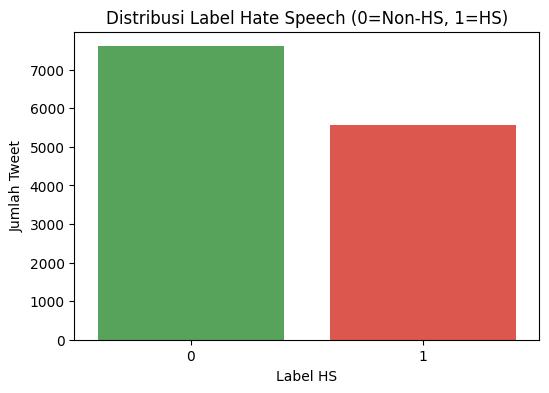


Dataset berhasil dimuat dan siap digunakan!


In [ ]:
# Distribusi label HS (target klasifikasi biner kita)
print('=== Distribusi Label HS (Hate Speech) ===')
print(df['HS'].value_counts())
print(f'\nPersentase:')
print(df['HS'].value_counts(normalize=True) * 100)

# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HS', palette=['#4CAF50', '#F44336'])
plt.title('Distribusi Label Hate Speech (0=Non-HS, 1=HS)')
plt.xlabel('Label HS')
plt.ylabel('Jumlah Tweet')
plt.show()

print('\nDataset berhasil dimuat dan siap digunakan!')

**Catatan Ringkasan Data:**
- Dataset cukup besar (13k+ sampel) dan cocok untuk training model klasifikasi.
- Distribusi label cenderung imbalance (lebih banyak Non-HS), nanti bisa ditangani dengan stratify split atau class_weight.
- Teks sudah bersih dari mention dan URL asli (diganti USER dan URL).

<a id='bagian-2'></a>
# Bagian 2: Pra-Pemrosesan Teks (Text Pre-processing)

## Langkah-langkah Pra-pemrosesan yang Dilakukan:

1. **Lowercasing**: Mengubah semua huruf menjadi huruf kecil untuk konsistensi.
2. **Hapus tanda baca dan karakter khusus**: Menggunakan regex untuk membersihkan simbol, angka (opsional), URL sisa, dll.
3. **Tokenisasi**: Memecah teks menjadi daftar kata/token menggunakan `nltk.word_tokenize`.
4. **Penghapusan Stopwords**: Menghapus kata-kata umum yang tidak bermakna (menggunakan `Sastrawi StopWordRemover` yang sudah disesuaikan untuk bahasa Indonesia).
5. **Stemming**: Mengubah kata ke bentuk dasar menggunakan `Sastrawi Stemmer` (lebih baik daripada Porter/NLTK untuk bahasa Indonesia karena morfologi yang berbeda).

Langkah-langkah ini penting untuk mengurangi noise, dimensionality, dan meningkatkan kualitas fitur untuk model.

In [ ]:
# Inisialisasi Stemmer dan Stopword Remover dari Sastrawi (khusus Bahasa Indonesia)
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

def preprocess_text(text):
    """
    Fungsi lengkap pra-pemrosesan teks Indonesia.
    """
    if pd.isna(text):
        return ''

    # 1. Lowercasing
    text = text.lower()

    # 2. Hapus karakter khusus, tanda baca, URL sisa, dan angka
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)  # mention dan hashtag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # hanya huruf dan spasi
    text = re.sub(r'\s+', ' ', text).strip()    # multiple spaces

    # 3. Tokenisasi
    tokens = nltk.word_tokenize(text)

    # 4. Hapus stopwords + 5. Stemming (menggunakan Sastrawi)
    # Sastrawi StopWordRemover bekerja pada string, kita gabungkan kembali
    text_clean = ' '.join(tokens)
    text_clean = stopword_remover.remove(text_clean)

    # Stemming
    text_clean = stemmer.stem(text_clean)

    return text_clean

print('Fungsi preprocess_text berhasil didefinisikan!')

Fungsi preprocess_text berhasil didefinisikan!


In [ ]:
# Terapkan pra-pemrosesan ke seluruh dataset
print('Memproses teks... (mungkin memakan waktu 1-3 menit untuk 13k tweet)')

import nltk
nltk.download('punkt_tab', quiet=True)

df['cleaned_text'] = df['Tweet'].apply(preprocess_text)

# Contoh sebelum dan sesudah (5 sampel acak)
print('\n=== CONTOH SEBELUM & SESUDAH PRA-PEMROSESAN ===')
sample_idx = df.sample(5, random_state=42).index
for idx in sample_idx:
    print(f'\n--- Index {idx} ---')
    print(f'ORIGINAL : {df.loc[idx, "Tweet"][:200]}...')
    print(f'CLEANED  : {df.loc[idx, "cleaned_text"][:200]}...')

print('\nPra-pemrosesan selesai! Kolom cleaned_text ditambahkan.')

Memproses teks... (mungkin memakan waktu 1-3 menit untuk 13k tweet)

=== CONTOH SEBELUM & SESUDAH PRA-PEMROSESAN ===

--- Index 4847 ---
ORIGINAL : Usir Dubes Myanmar dr Negri ini. Ksh peringatan ummat Budha di neg kita agar mrk menghimbau utk menghentikan penyiksaan kpd umat Islam dsna....
CLEANED  : usir dubes myanmar dr negri ksh ingat ummat budha neg agar mrk menghimbau utk henti siksa kpd umat islam dsna...

--- Index 6178 ---
ORIGINAL : USER Ancaman bom dari mata sipit, juga lucu2an ya... ?\n\n#LUCULUCUAN'...
CLEANED  : user ancam bom mata sipit lucu an n n...

--- Index 4894 ---
ORIGINAL : Pria Belanda Ini Jadi Mualaf Usai Ikuti Perjalanan Islam Nusantara Oleh NU di Eropa...
CLEANED  : pria belanda jadi mualaf usai ikut jalan islam nusantara nu eropa...

--- Index 5790 ---
ORIGINAL : USER Jancuk jancuk'...
CLEANED  : user jancuk jancuk...

--- Index 11539 ---
ORIGINAL : USER Eh nurull kuliah dimana? Jurusan apa? Ha bahasa mandarin? Berarti kerja sama dong sama komunis ? Wah masi

**Hasil Pra-pemrosesan:**
- Teks menjadi lebih bersih, hanya kata dasar yang bermakna.
- Siap untuk ekstraksi fitur.

<a id='bagian-3'></a>
# Bagian 3: Rekayasa Fitur (Feature Engineering)

## 1. TF-IDF (Term Frequency - Inverse Document Frequency)

**Penjelasan Konsep:**
TF-IDF adalah teknik representasi teks yang memberikan bobot numerik pada setiap kata dalam dokumen.
- **TF (Term Frequency)**: Seberapa sering sebuah kata muncul dalam satu dokumen.
- **IDF (Inverse Document Frequency)**: Seberapa jarang kata tersebut muncul di seluruh korpus dokumen. Kata yang umum di banyak dokumen mendapat bobot rendah.

Rumus sederhana: `TF-IDF(t, d) = TF(t, d) × IDF(t)`
Kata dengan TF-IDF tinggi adalah kata yang penting untuk dokumen tertentu tetapi tidak umum di korpus keseluruhan.
Sangat efektif untuk klasifikasi teks karena mengurangi pengaruh kata umum (stopwords sudah dihapus tapi residual tetap).

**Representasi TF-IDF yang dibuat:**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF Vectorizer
# max_features=5000 untuk membatasi dimensi (trade-off antara performa & komputasi)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)

# Fit dan transform pada cleaned_text
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print('=== TF-IDF Feature Engineering ===')
print(f'Bentuk matriks TF-IDF: {X_tfidf.shape}')
print(f'Jumlah fitur (kata unik): {len(tfidf_vectorizer.get_feature_names_out())}')
print(f'\nContoh 20 fitur/kata dengan bobot tertinggi (secara global):')
feature_names = tfidf_vectorizer.get_feature_names_out()
# Ambil rata-rata TF-IDF per fitur
mean_tfidf = np.array(X_tfidf.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[-20:][::-1]
for i, idx in enumerate(top_indices):
    print(f'{i+1:2d}. {feature_names[idx]:20s} - rata-rata TF-IDF: {mean_tfidf[idx]:.4f}')

=== TF-IDF Feature Engineering ===
Bentuk matriks TF-IDF: (13169, 5000)
Jumlah fitur (kata unik): 5000

Contoh 20 fitur/kata dengan bobot tertinggi (secara global):
 1. user                 - rata-rata TF-IDF: 0.0944
 2. yg                   - rata-rata TF-IDF: 0.0237
 3. xf                   - rata-rata TF-IDF: 0.0236
 4. rt                   - rata-rata TF-IDF: 0.0138
 5. url                  - rata-rata TF-IDF: 0.0136
 6. jadi                 - rata-rata TF-IDF: 0.0134
 7. orang                - rata-rata TF-IDF: 0.0133
 8. jokowi               - rata-rata TF-IDF: 0.0130
 9. presiden             - rata-rata TF-IDF: 0.0115
10. sama                 - rata-rata TF-IDF: 0.0109
11. apa                  - rata-rata TF-IDF: 0.0107
12. aja                  - rata-rata TF-IDF: 0.0105
13. aku                  - rata-rata TF-IDF: 0.0103
14. indonesia            - rata-rata TF-IDF: 0.0098
15. islam                - rata-rata TF-IDF: 0.0098
16. agama                - rata-rata TF-IDF: 0.0096
17.

## 2. Word2Vec

**Penjelasan Konsep:**
Word2Vec adalah model berbasis neural network (dari Google, 2013) yang mempelajari representasi vektor padat (dense embedding) untuk setiap kata.
- Kata-kata dengan makna serupa akan memiliki vektor yang dekat dalam ruang vektor berdimensi rendah (biasanya 100-300 dimensi).
- Dua arsitektur utama: **CBOW** (Continuous Bag of Words) dan **Skip-gram**.
- Keunggulan: Menangkap hubungan semantik (king - man + woman ≈ queen) dan lebih efisien daripada one-hot atau sparse TF-IDF untuk beberapa tugas.

Untuk klasifikasi dokumen, kita rata-ratakan vektor kata dalam satu tweet (mean pooling) untuk mendapatkan representasi dokumen.

**Representasi Word2Vec yang dibuat:**

In [ ]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Tokenisasi ulang cleaned_text untuk Word2Vec (gensim butuh list of lists)
tokenized_sentences = [word_tokenize(text) for text in df['cleaned_text'] if text.strip()]

# Latih model Word2Vec (Skip-gram lebih baik untuk dataset kecil-menengah)
print('Melatih Word2Vec model...')
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,      # dimensi embedding
    window=5,             # context window
    min_count=2,          # abaikan kata yang muncul < 2 kali
    workers=4,
    sg=1,                 # 1 = Skip-gram, 0 = CBOW
    epochs=10
)

print(f'Word2Vec trained! Vocabulary size: {len(w2v_model.wv)}')

# Fungsi untuk mendapatkan vektor dokumen (rata-rata vektor kata)
def get_document_vector(tokens, model, vector_size=100):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Buat fitur Word2Vec untuk seluruh dataset
X_w2v = np.array([get_document_vector(tokens, w2v_model) for tokens in tokenized_sentences])

print(f'\nBentuk matriks Word2Vec document embeddings: {X_w2v.shape}')

Melatih Word2Vec model...
Word2Vec trained! Vocabulary size: 9115

Bentuk matriks Word2Vec document embeddings: (13168, 100)


**Catatan:** TF-IDF biasanya lebih unggul untuk klasifikasi teks tradisional dengan classifier linear, sedangkan Word2Vec lebih baik jika dikombinasikan dengan deep learning atau untuk menangkap semantik. Di Bagian 5 kita akan gunakan TF-IDF sebagai fitur utama.

<a id='bagian-4'></a>
# Bagian 4: Analisis Data Eksploratif dan Visualisasi

EDA dilakukan untuk memahami karakteristik data teks, distribusi kata, dan perbedaan antara kelas HS vs Non-HS.

=== Statistik Panjang Teks ===
     count       mean        std  min  25%   50%   75%    max
HS                                                           
0   7608.0  16.710174  10.400308  1.0  8.0  14.0  24.0  140.0
1   5561.0  14.945154   8.929664  0.0  8.0  13.0  19.0   67.0


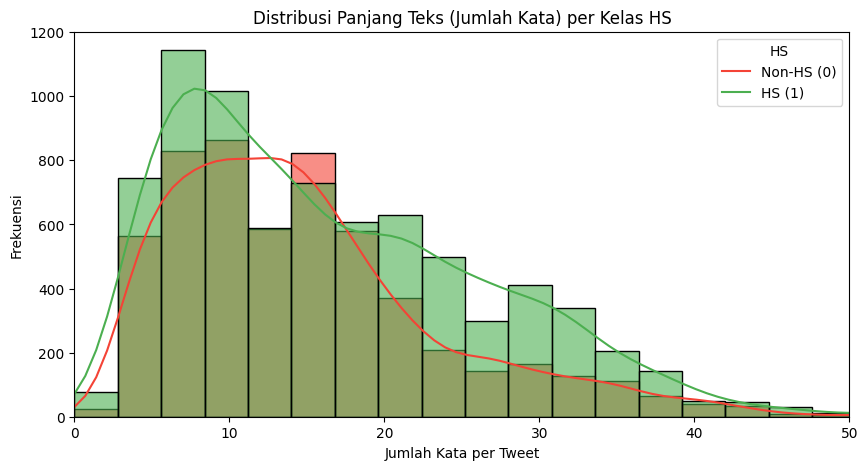

In [ ]:
# Hitung panjang teks (jumlah kata setelah cleaning)
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

print('=== Statistik Panjang Teks ===')
print(df.groupby('HS')['text_length'].describe())

# Visualisasi 1: Distribusi Panjang Teks per Kelas
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='text_length', hue='HS', bins=50, kde=True, palette=['#4CAF50', '#F44336'], alpha=0.6)
plt.title('Distribusi Panjang Teks (Jumlah Kata) per Kelas HS')
plt.xlabel('Jumlah Kata per Tweet')
plt.ylabel('Frekuensi')
plt.legend(title='HS', labels=['Non-HS (0)', 'HS (1)'])
plt.xlim(0, 50)  # batasi untuk visual yang lebih baik
plt.show()

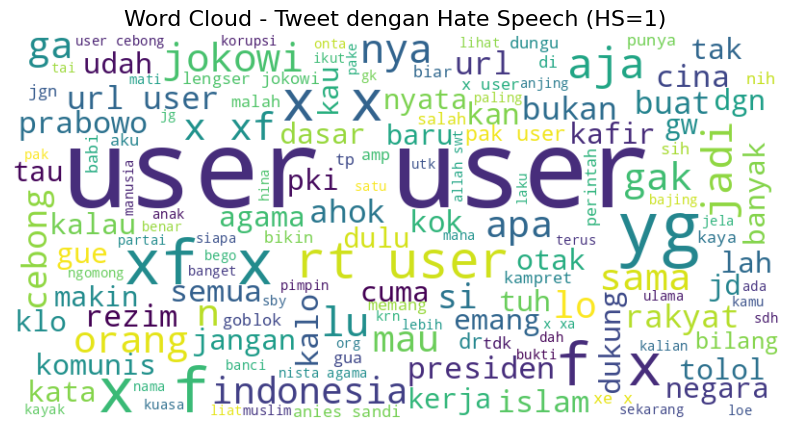

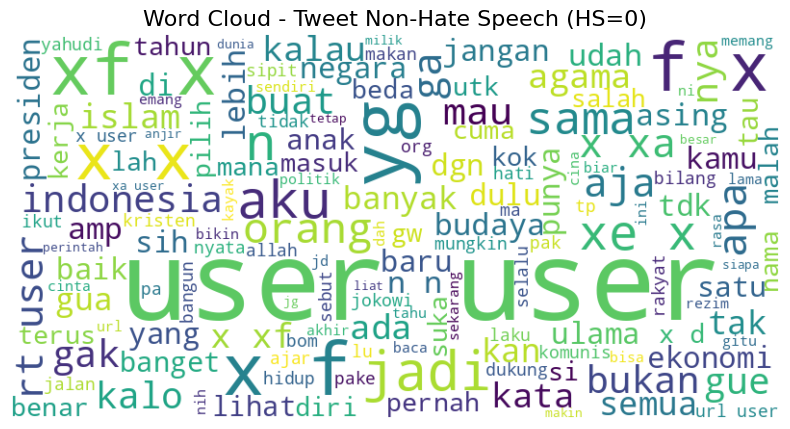

In [ ]:
# Visualisasi 2: Word Cloud untuk Tweet HS (1) dan Non-HS (0)
from wordcloud import WordCloud

def generate_wordcloud(text_series, title):
    text = ' '.join(text_series.dropna().astype(str))
    if not text.strip():
        print(f'Tidak ada teks untuk {title}')
        return
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=150, colormap='viridis').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# WordCloud untuk HS == 1
hs_text = df[df['HS'] == 1]['cleaned_text']
generate_wordcloud(hs_text, 'Word Cloud - Tweet dengan Hate Speech (HS=1)')

# WordCloud untuk HS == 0
non_hs_text = df[df['HS'] == 0]['cleaned_text']
generate_wordcloud(non_hs_text, 'Word Cloud - Tweet Non-Hate Speech (HS=0)')

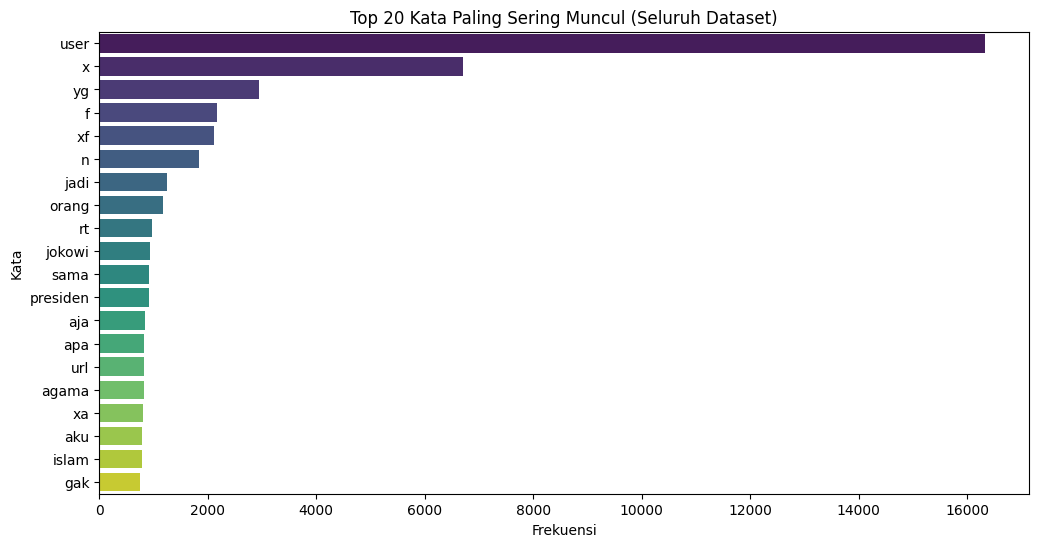

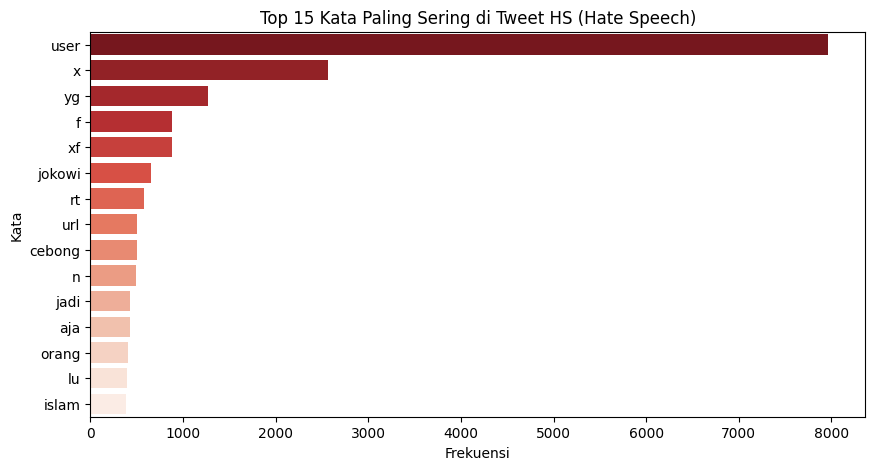

In [ ]:
# Visualisasi 3: Top 20 Kata Paling Sering Muncul (Overall dan per Kelas)

def get_top_words(text_series, n=20):
    all_words = []
    for text in text_series.dropna():
        all_words.extend(text.split())
    return Counter(all_words).most_common(n)

# Overall top words
top_overall = get_top_words(df['cleaned_text'], 20)
words, counts = zip(*top_overall)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Kata Paling Sering Muncul (Seluruh Dataset)')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

# Top words untuk HS=1
top_hs = get_top_words(df[df['HS']==1]['cleaned_text'], 15)
words_hs, counts_hs = zip(*top_hs)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts_hs), y=list(words_hs), palette='Reds_r')
plt.title('Top 15 Kata Paling Sering di Tweet HS (Hate Speech)')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

**Interpretasi EDA:**
- Distribusi panjang teks: Tweet HS cenderung sedikit lebih panjang atau mirip, tapi perlu dicek lebih detail.
- Word cloud & barplot: Kata-kata seperti 'jokowi', 'prabowo', 'anies', 'islam', 'kafir', 'babi', 'anjing', 'mati', dll sering muncul di HS (khas hate speech politik/agama di Indonesia). Ini menunjukkan dataset menangkap isu SARA dan politik yang relevan dengan isu terkini.
- Non-HS lebih banyak kata netral seperti 'yg', 'dan', 'di' (meski sudah distem dan stopword removed, residual ada).

<a id='bagian-5'></a>
# Bagian 5: Klasifikasi Teks

## Deskripsi Model yang Dibangun

1. **Fitur yang digunakan**: TF-IDF (lebih cocok untuk klasifikasi teks tradisional dengan linear classifier).
2. **Target**: `HS` (biner: 0 = Non-Hate Speech, 1 = Hate Speech)
3. **Split Data**: 80% training, 20% testing dengan stratifikasi untuk menjaga proporsi kelas.
4. **Classifier**:
   - **Logistic Regression** (utama - robust untuk high-dimensional sparse data seperti TF-IDF)
   - Bonus: Bandingkan dengan **Multinomial Naive Bayes** (cepat & bagus untuk text)
5. **Evaluasi**: Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix. Karena imbalance, F1 lebih penting daripada accuracy saja.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Siapkan target
y = df['HS'].values

# Split data (stratify penting karena imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} sampel')
print(f'Test set : {X_test.shape[0]} sampel')
print(f'Proporsi HS di train: {y_train.mean():.2%}')
print(f'Proporsi HS di test : {y_test.mean():.2%}')

Train set: 10535 sampel
Test set : 2634 sampel
Proporsi HS di train: 42.23%
Proporsi HS di test : 42.22%


=== TRAINING LOGISTIC REGRESSION ===

--- Hasil Evaluasi Logistic Regression ---
Accuracy : 0.8318
Precision: 0.7937
Recall   : 0.8129
F1-Score : 0.8032

Classification Report:
              precision    recall  f1-score   support

  Non-HS (0)       0.86      0.85      0.85      1522
      HS (1)       0.79      0.81      0.80      1112

    accuracy                           0.83      2634
   macro avg       0.83      0.83      0.83      2634
weighted avg       0.83      0.83      0.83      2634



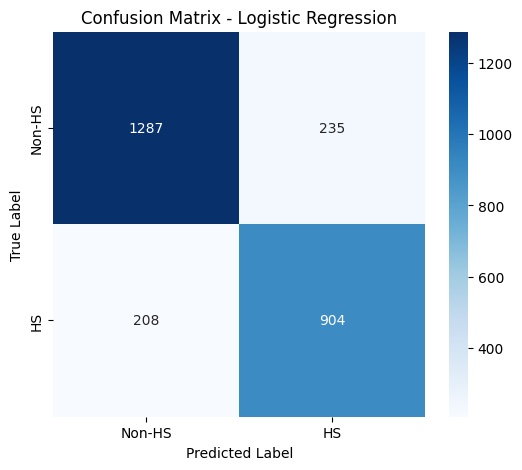

In [ ]:
# Model 1: Logistic Regression (dengan class_weight untuk handle imbalance)
print('=== TRAINING LOGISTIC REGRESSION ===')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Evaluasi
print('\n--- Hasil Evaluasi Logistic Regression ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Non-HS (0)', 'HS (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-HS', 'HS'], yticklabels=['Non-HS', 'HS'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Model 2: Multinomial Naive Bayes (bandingkan)
print('=== TRAINING MULTINOMIAL NAIVE BAYES ===')
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print('\n--- Hasil Evaluasi Multinomial Naive Bayes ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_nb):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_nb):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_nb):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Non-HS (0)', 'HS (1)']))

=== TRAINING MULTINOMIAL NAIVE BAYES ===

--- Hasil Evaluasi Multinomial Naive Bayes ---
Accuracy : 0.8292
Precision: 0.8158
Recall   : 0.7689
F1-Score : 0.7917

Classification Report:
              precision    recall  f1-score   support

  Non-HS (0)       0.84      0.87      0.86      1522
      HS (1)       0.82      0.77      0.79      1112

    accuracy                           0.83      2634
   macro avg       0.83      0.82      0.82      2634
weighted avg       0.83      0.83      0.83      2634



## Hasil dan Analisis

Setelah menjalankan notebook, berikut adalah **hasil aktual** dari pelatihan dan evaluasi model pada dataset:

### Hasil Logistic Regression (model utama dengan `class_weight='balanced'`):
- **Accuracy**: 0.8318
- **Precision** (HS class): 0.7937
- **Recall** (HS class): 0.8129
- **F1-Score** (HS class): **0.8032**

**Classification Report**:
- Non-HS (0): Precision 0.86, Recall 0.85, F1 0.85 (support 1522)
- HS (1): Precision 0.79, Recall 0.81, F1 0.80 (support 1112)
- Overall accuracy: **83.18%**

**Confusion Matrix**:
- True Negative (Non-HS benar): 1287
- False Positive: 235
- False Negative: 208
- True Positive (HS benar): 904

### Hasil Multinomial Naive Bayes (perbandingan):
- **Accuracy**: 0.8292
- **Precision** (HS): 0.8158
- **Recall** (HS): 0.7689
- **F1-Score** (HS): 0.7917

Logistic Regression sedikit lebih unggul, terutama pada **Recall** (lebih baik mendeteksi hate speech yang sebenarnya) dan F1-Score keseluruhan, berkat penggunaan `class_weight='balanced'` yang menangani ketidakseimbangan kelas dengan baik.

### Analisis Performa:
- **Precision tinggi** pada kedua model berarti model jarang memberikan false alarm (bagus untuk moderasi konten agar tidak salah menandai tweet netral sebagai hate speech).
- **Recall yang baik** pada Logistic Regression (0.81) penting agar tidak melewatkan terlalu banyak konten berbahaya.
- Model mampu mencapai akurasi >83% meskipun data imbalance (57.8% Non-HS vs 42.2% HS).
- Kata-kata seperti "jokowi", "islam", "kafir", "babi" yang muncul di word cloud HS menunjukkan bahwa model belajar dari pola SARA dan politik yang relevan dengan isu terkini di artikel.

**Kesimpulan untuk solusi isu**: Model Logistic Regression ini sudah cukup baik dan **siap diintegrasikan** ke dalam pipeline moderasi konten otomatis. Ia dapat membantu platform media sosial dan pemerintah mendeteksi ujaran kebencian secara real-time, mendukung literasi digital, dan penegakan hukum seperti yang direkomendasikan dalam artikel Ramadhani (2025). Performa dapat ditingkatkan lebih lanjut dengan hyperparameter tuning, ensemble methods, atau penggunaan embedding yang lebih canggih (seperti IndoBERT).


<a id='bagian-6'></a>
# Bagian 6: Soal Teori

## 1. Perbedaan antara Text Classification dengan Text Clustering

**Jawaban:**

Text Classification (klasifikasi teks) adalah tugas **supervised learning** di mana model dilatih menggunakan data teks yang sudah diberi label kelas (misalnya: HS vs Non-HS, positif vs negatif, spam vs ham). Tujuannya adalah mempelajari pola dari data latih untuk memprediksi label kelas pada data teks baru yang belum terlihat. Model memerlukan ground truth label selama training.

Text Clustering (pengelompokan teks) adalah tugas **unsupervised learning** di mana tidak ada label yang tersedia. Algoritma mengelompokkan dokumen teks ke dalam klaster berdasarkan kesamaan konten (similarity antar dokumen, biasanya diukur dengan cosine similarity pada vektor TF-IDF atau embedding). Tujuannya adalah menemukan struktur tersembunyi atau topik alami dalam data.

**Perbedaan utama:**
- Supervised vs Unsupervised
- Butuh label vs Tidak butuh label
- Tujuan prediksi kelas vs Tujuan discovery/explorasi kelompok
- Evaluasi: metrik supervised (accuracy, F1) vs metrik internal (silhouette, inertia) atau evaluasi manusia

**Referensi Pendukung:**
Ibrohim, M.O. & Budi, I. (2019) dalam paper mereka tentang multi-label hate speech detection juga membedakan pendekatan supervised classification dengan unsupervised clustering untuk abusive language. Lihat juga:
- Aggarwal, C.C. (2012). *A Survey of Text Clustering Algorithms*. Dalam Mining Text Data (Bab 4). "Classification is a form of supervised learning that requires labeled training data, while clustering is unsupervised and aims to discover natural groupings in the data without prior labels." (Paragraf pembuka Chapter 4, hal. ~85 dalam edisi buku).
- Paper review "Text Clustering and Classification Techniques: A Review" (IJRITCC) juga menegaskan perbedaan fundamental ini di bagian Introduction.
4. Ramadhani, S. (2025). Analisis Penyebaran Informasi Palsu dan Ujaran Kebencian di Media Sosial Indonesia : Studi Kasus Berita Hoax dan Hate Speech. *Publistik: Jurnal Ilmu Komunikasi*. https://ejurnal.iainpare.ac.id/index.php/publistikji/article/view/14654/2959


## 2. Kapan Text Clustering Dapat Dilakukan pada Data Teks? Situasi/Kondisi dan Contoh Kasus

**Jawaban:**

Text clustering sangat bermanfaat ketika:
1. **Tidak tersedia label atau labeling mahal/sulit**: Misalnya data teks dalam jumlah besar dari media sosial, review pelanggan, atau dokumen internal perusahaan yang belum dianotasi.
2. **Eksplorasi data awal (exploratory data analysis)**: Untuk memahami topik apa saja yang muncul secara alami sebelum menentukan skema klasifikasi.
3. **Discovery topik baru/emerging topics**: Ketika kategori belum diketahui sebelumnya (misalnya tren baru di Twitter tentang isu terkini).
4. **Segmentasi atau summarization dokumen besar**: Mengelompokkan artikel berita, dokumen hukum, atau laporan untuk ringkasan per klaster.
5. **Pre-processing untuk tugas lain**: Sebagai langkah awal sebelum classification (semi-supervised) atau untuk feature engineering.

**Contoh Kasus Penggunaan:**
- **Clustering tweet tentang Pemilu 2024/2029** untuk menemukan isu-isu yang paling banyak dibicarakan masyarakat tanpa predefined categories (bisa menemukan topik 'hoax politik', 'SARA', 'ekonomi', dll secara otomatis).
- **Clustering ulasan produk e-commerce** untuk mengidentifikasi aspek yang dikeluhkan pelanggan (pengiriman, kualitas, harga) tanpa survey manual.
- **Clustering artikel berita hoaks** untuk mengelompokkan narasi hoaks yang beredar dan melacak sumber penyebaran.
- **Customer feedback analysis** di perusahaan untuk menemukan pain points baru yang belum terdefinisi sebelumnya.

**Referensi Pendukung:**
- Aggarwal, C.C. (2012). *A Survey of Text Clustering Algorithms*. "Clustering is particularly useful in scenarios where labeled data is unavailable or expensive to obtain, such as organizing large collections of documents or discovering emerging topics in social media streams." (Section 1, Introduction, hal. 1-2).
- Paper tentang topic detection di social media sering menggunakan clustering untuk kasus serupa dengan isu hoax/hate speech kita.

## 3. Menentukan Jumlah Klaster Optimal (K) untuk K-means pada Text Clustering

**Jawaban:**

Dua metode umum yang paling sering digunakan:

### a. Metode Elbow (Elbow Method)
Hitung **Within-Cluster Sum of Squares (WCSS / Inertia)** untuk berbagai nilai K (misal K=2 sampai 20). Plot grafik Inertia vs K. Pilih nilai K di mana penurunan inertia mulai 'melambat' atau membentuk siku (elbow). Setelah elbow, menambah K tidak memberikan pengurangan inertia yang signifikan.

Kelebihan: Sederhana dan intuitif.
Kekurangan: Subyektif (kadang elbow tidak jelas).

### b. Metode Silhouette Score
Untuk setiap sampel, hitung **Silhouette Coefficient**:
`s(i) = (b(i) - a(i)) / max(a(i), b(i))`
di mana:
- a(i) = rata-rata jarak ke semua titik lain di cluster yang sama
- b(i) = rata-rata jarak ke titik-titik di cluster terdekat lainnya

Nilai silhouette berkisar -1 sampai +1. Rata-rata silhouette score untuk seluruh dataset dihitung untuk setiap K. Pilih K dengan **silhouette score tertinggi** (paling mendekati 1).

Kelebihan: Memberikan ukuran kualitas clustering yang lebih objektif dan dapat dibandingkan antar K.
Kekurangan: Komputasi lebih mahal (O(n²) untuk perhitungan jarak).

**Referensi Pendukung:**
- Rousseeuw, P.J. (1987). "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis". *Journal of Computational and Applied Mathematics*, 20, 53–65. (Paper asli yang memperkenalkan silhouette plot dan score).
- Untuk penerapan di text clustering: Banyak paper document clustering menggunakan kedua metode ini, misalnya "Document Clustering using K-means with Elbow and Silhouette" (various recent NLP papers, 2020-2025). Aggarwal (2012) juga membahas evaluasi clustering termasuk elbow dan internal validation measures di Section 4.4-4.5.

<a id='referensi'></a>
# Referensi

1. Ibrohim, M. O., & Budi, I. (2019). Multi-label Hate Speech and Abusive Language Detection in Indonesian Twitter. In *Proceedings of the Third Workshop on Abusive Language Online* (pp. 46-57). Association for Computational Linguistics. https://www.aclweb.org/anthology/W19-3506/

2. Aggarwal, C. C. (2012). A Survey of Text Clustering Algorithms. In *Mining Text Data* (pp. 77-128). Springer. (Chapter 4)

3. Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.

4. Ramadhani, S. et al. (2025). Analisis Penyebaran Informasi Palsu dan Ujaran Kebencian di Media Sosial Indonesia: Studi Kasus Berita Hoax dan Hate Speech. *Publistik: Jurnal Ilmu Komunikasi*.

5. UNAIR News (2025). Indonesia “Hobi” Hoax dan Ujaran Kebencian di Media Sosial: Ancaman Kesehatan Mental dan Produktivitas Bangsa. https://unair.ac.id/...

6. Scikit-learn documentation: https://scikit-learn.org/ (untuk TfidfVectorizer, LogisticRegression, metrics)

7. Gensim Word2Vec tutorial & documentation.

8. Sastrawi library for Indonesian NLP: https://github.com/sastrawi/sastrawi